# CLIP

**The big Idea:**

- CLIP is trained to match images and text in a shared embedding space.

- Instead of predicting labels, it learns by contrastive learning:

  - A batch of images and their corresponding captions is given.

  - The model is trained so that the image embedding is close to its caption embedding and far from others.



In [1]:
%pip install ftfy regex tqdm
%pip install git+https://github.com/openai/CLIP.git

%pip install -q datasets torchvision

import os
import torch
import clip
from PIL import Image
import torchvision.transforms as T

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/1b/yw3k2nwd14gfcn_47x1fkm6r0000gn/T/pip-req-build-5fmdek5y
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/1b/yw3k2nwd14gfcn_47x1fkm6r0000gn/T/pip-req-build-5fmdek5y
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Contrastive Loss

The Training Objective

- Use contrastive loss (InfoNCE / softmax cross-entropy).

- Similarity is measured by cosine similarity between image & text embeddings.

- The loss encourages the correct image–text pairs to align and mismatched pairs to separate.

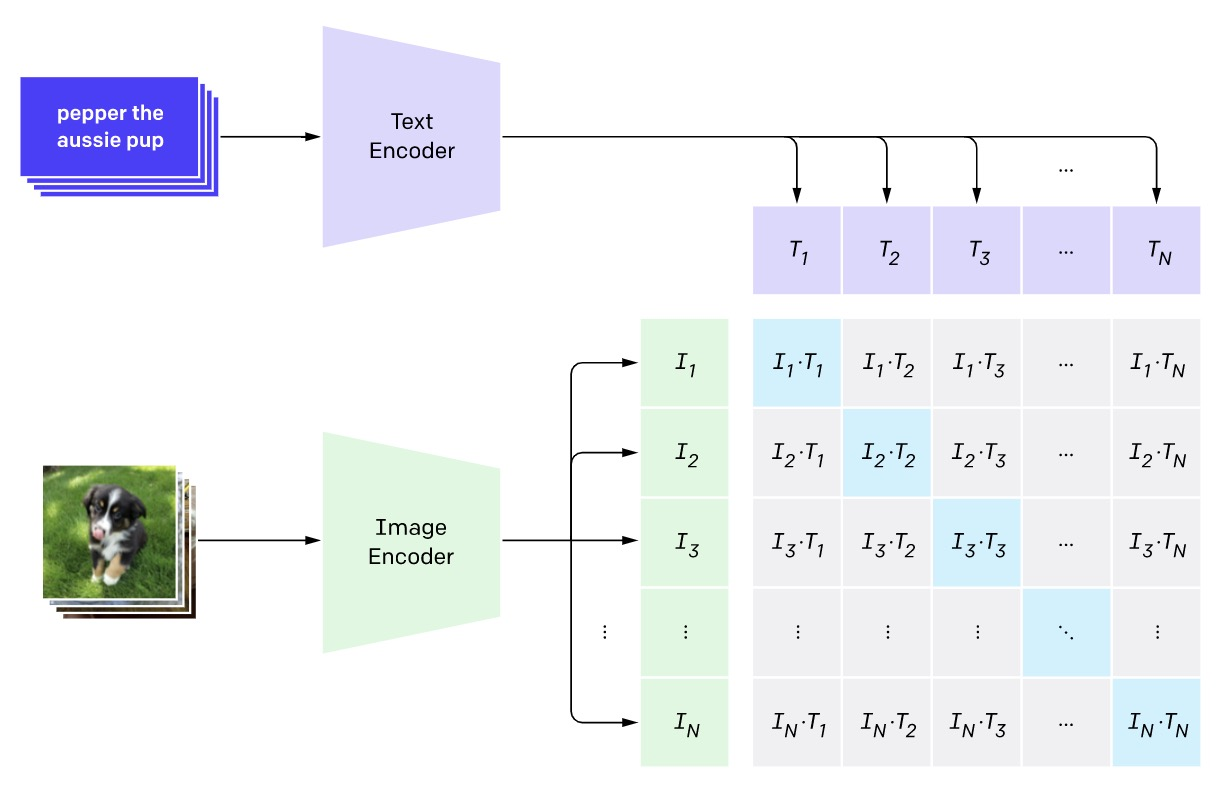

In [2]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"Device: {device}")


# Load model and preprocess transforms
model, preprocess = clip.load("ViT-B/32", device=device)

# image and text encoders
image_encoder = model.visual
text_encoder = model.transformer

Device: mps


In [3]:
# The text is decomposed into smaller units (tokens) using Byte Pair Encoding (BPE). 
# Common words stay whole, while rare words are split into sub-word units.
clip.tokenize("hello world!")

tensor([[49406,  3306,  1002,   256, 49407,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

In [4]:
from clip.simple_tokenizer import SimpleTokenizer

tokenizer = SimpleTokenizer()
decoded = tokenizer.decode([3306])
#decoded = tokenizer.decode([1002]) #'world'
#decoded = tokenizer.decode([49407]) #'<|endoftext|>'
decoded

'hello '

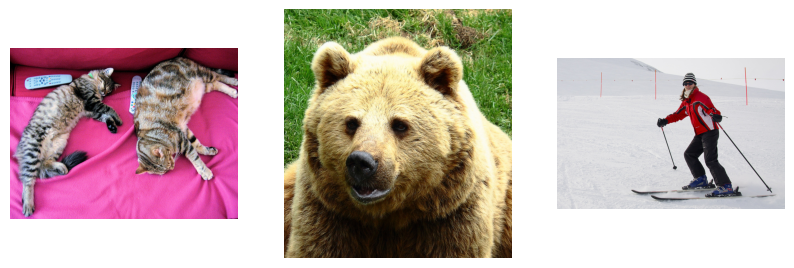

In [5]:
'''
# 1. Load: Fetch 3 images via URL and their corresponding text descriptions.
# 2. Normalize: Convert images to RGB format to ensure compatibility with the model.
# 3. Verify: Display images side-by-side to confirm successful loading before processing with CLIP.
'''

# Dataset creation from COCO (image-caption pairs)
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import requests
from io import BytesIO
import torchvision.transforms as T
import matplotlib.pyplot as plt


captions = [
    "here are two cats laying down with two remotes",
    "an bear in the grass",
    "a man with a red jacket is skiing in the snow"
]

image_urls = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",
    "http://images.cocodataset.org/val2017/000000000285.jpg",
    "http://images.cocodataset.org/val2017/000000000785.jpg",
]

images = []
for url in image_urls:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    images.append(img)

# Display images
plt.figure(figsize=(10,4))
for i, img in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [9]:
# image processing
'''
1. Load: Fetch 3 images via URL and their corresponding text descriptions.
2. Normalize: Convert images to RGB format to ensure compatibility with the model.
3. Verify: Display images side-by-side to confirm successful loading before processing with CLIP.
'''
image_tensors = [preprocess(img) for img in images]
image_batch = torch.stack(image_tensors).to(device) # Stack into a batch tensor: [batch_size, channels, height, width]
print(f"Image batch shape: {image_batch.shape}")

# Tokenize
text_batch = clip.tokenize(captions).to(device)
print(f"Text batch shape: {text_batch.shape}")

Image batch shape: torch.Size([3, 3, 224, 224])
Text batch shape: torch.Size([3, 77])


### CLIP functions
The two CLIP functions are:
- encode_image()
- encode_text()

and REMEMBER: the contrastive loss is bidirectional!

Without bidirectional loss, the model might learn:

- Images that map well to texts, but texts that don't map back well to images
- Or vice versa

*The bidirectional loss ensures symmetric, high-quality embeddings where both modalities can effectively retrieve each other!*

In [10]:
from torch.cuda.random import device_count
# -- Contrastive Loss Implementation --
with torch.no_grad(): # just because we are not really training
  # Forward passes (Extracting Features)
  image_features = model.encode_image(image_batch)
  text_features = model.encode_text(text_batch)

  # Normalize features (L2 normalization) -> This step makes all the vectors the same "length"
  image_features = image_features / image_features.norm(dim=-1, keepdim=True)
  text_features = text_features / text_features.norm(dim=-1, keepdim=True)

  # Get logit scale factor (learnable temperature parameter), it helps the model be more "confident" during training
  logit_scale = model.logit_scale.exp()
  print(f"Logit scale: {logit_scale.item():.2f}")

  '''
  Compute logits/similarity (scaled cosine similarity):
  - logits_per_image -> "Given this image, which text is the best match?"
  - logits_per_text -> "Given this text, which image is the best match?"
  '''
  logits_per_image = logit_scale * image_features @ text_features.t() #The @ symbol performs a matrix multiplication
  logits_per_text = logits_per_image.t() #.t -> transpose

  # Targets: take the diagonal elements (image i should match text i)
  targets = torch.arange(len(image_batch), device=device)

  # InfoNCE loss: cross-entropy
  loss_i2t = F.cross_entropy(logits_per_image, targets)
  loss_t2i = F.cross_entropy(logits_per_text, targets)

  # Combined loss
  contrastive_loss = (loss_i2t + loss_t2i) / 2

  print(f"Contrastive Loss: {contrastive_loss:.4f}")

Logit scale: 100.00
Contrastive Loss: 0.0000


We can see that we have respectively:
- 3 images, each of them encoded into a 512-dimensional feature vector
- 3 text description, each of them encoded into a 512-dimensional feature vector

In [11]:
image_features.shape, text_features.shape

(torch.Size([3, 512]), torch.Size([3, 512]))

In [12]:
'''
Questo risultato rappresenta la matrice di similarità finale. 
In termini semplici, è la tabella dei "voti" che il modello ha assegnato a ogni possibile combinazione tra le tue immagini e le tue frasi.
'''
logits_per_image.shape

torch.Size([3, 3])

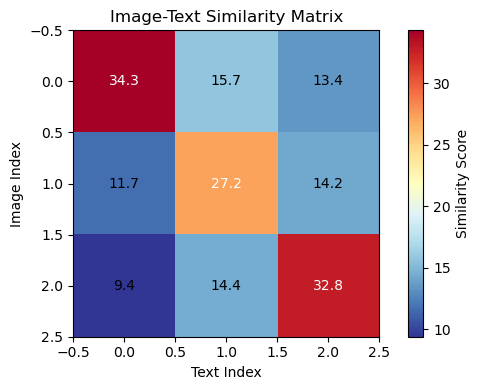


Similarity Scores:
Image 1 <-> Caption 1: 34.28
Image 2 <-> Caption 2: 27.20
Image 3 <-> Caption 3: 32.81


In [13]:
# Display similarity matrix
similarity_matrix = logits_per_image.cpu().numpy()

plt.figure(figsize=(6, 4))
plt.imshow(similarity_matrix, cmap='RdYlBu_r')
plt.colorbar(label='Similarity Score')
plt.xlabel('Text Index')
plt.ylabel('Image Index')
plt.title('Image-Text Similarity Matrix')

# Add text annotations
for i in range(len(images)):
    for j in range(len(captions)):
        plt.text(j, i, f'{similarity_matrix[i,j]:.1f}',
                ha='center', va='center',
                color='white' if abs(similarity_matrix[i,j]) > similarity_matrix.max()/2 else 'black')

plt.tight_layout()
plt.show()

# Print individual similarities
print(f"\nSimilarity Scores:")
for i, (img_idx, cap_idx) in enumerate(zip(range(len(images)), range(len(captions)))):
    score = similarity_matrix[img_idx, cap_idx]
    print(f"Image {img_idx+1} <-> Caption {cap_idx+1}: {score:.2f}")

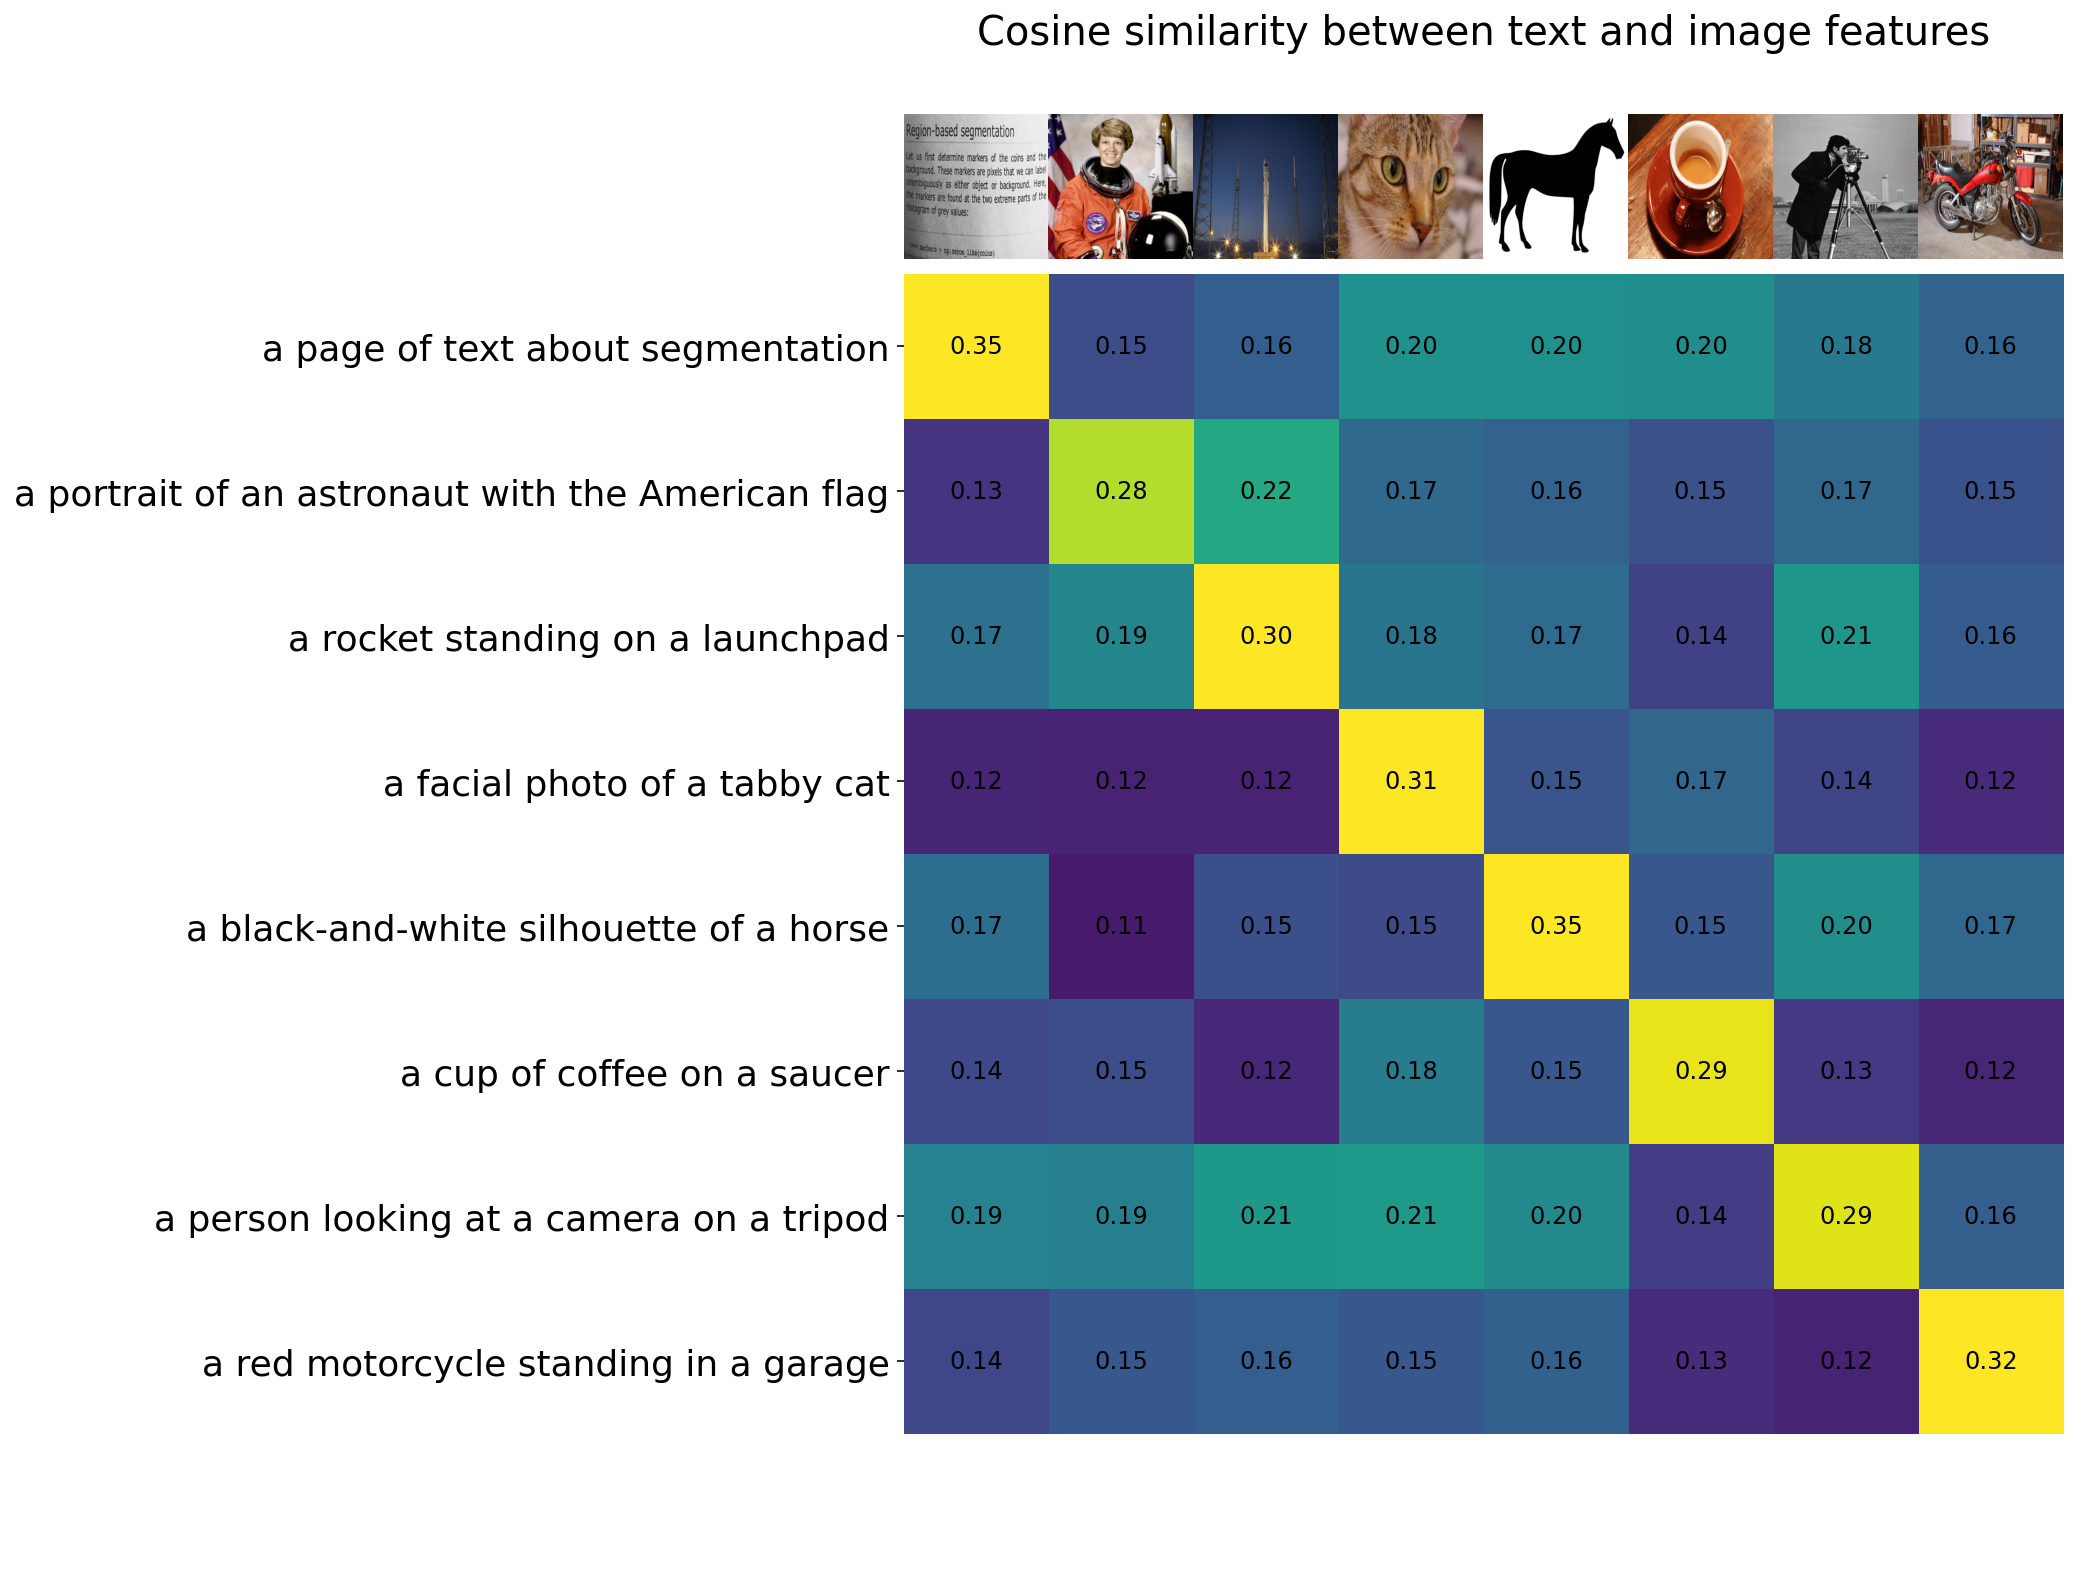![image.png](
*testo in corsivo*)![image.png](
  
)

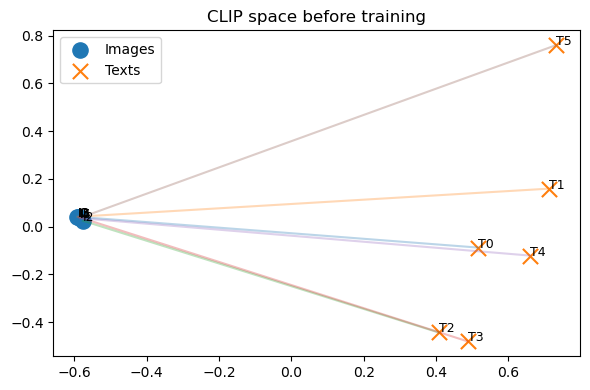

Epoch 000 | loss = 2.7270


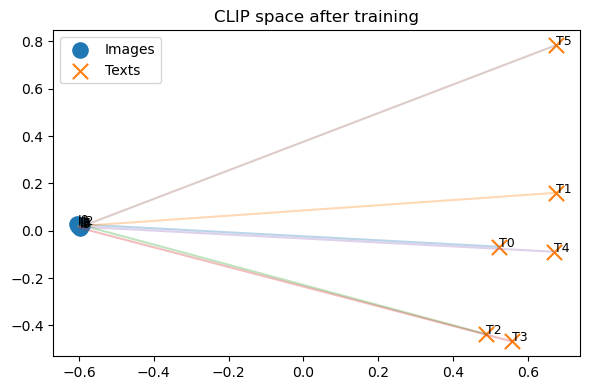

Epoch 020 | loss = 0.8682


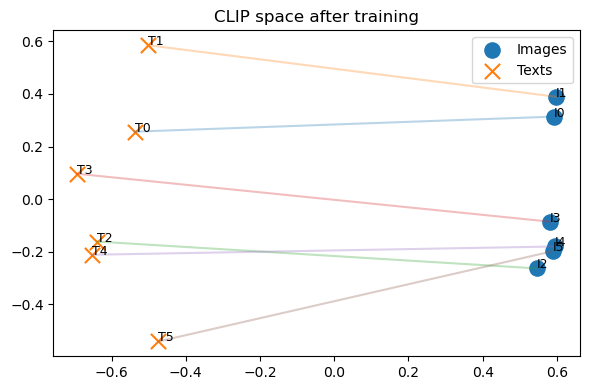

Epoch 040 | loss = 0.0263


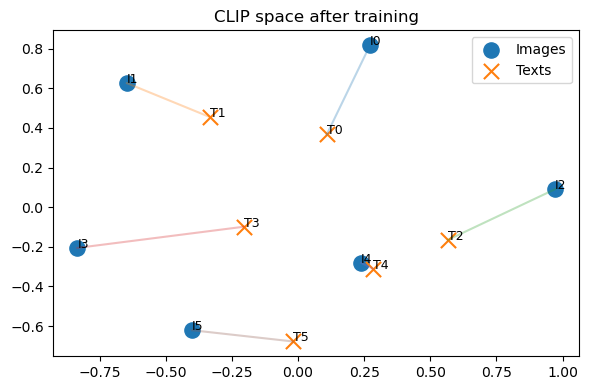

Epoch 060 | loss = 0.0022


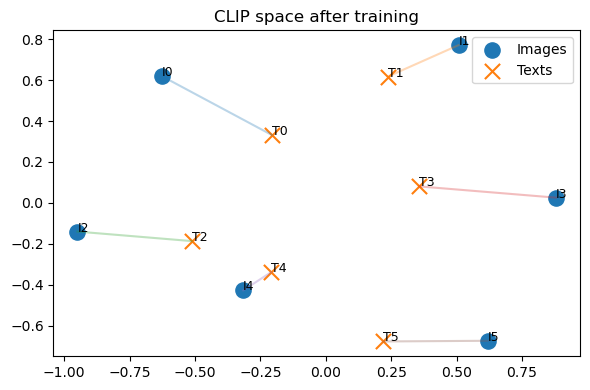

Epoch 080 | loss = 0.0008


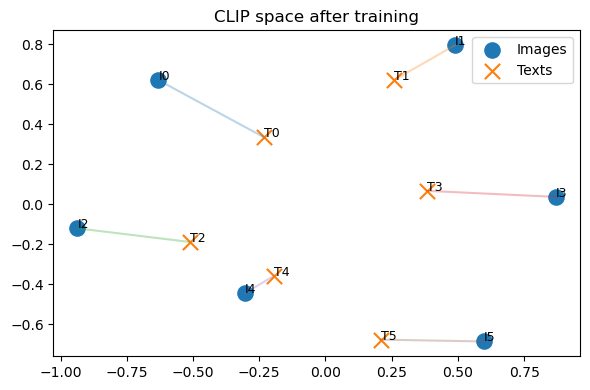

Epoch 099 | loss = 0.0005


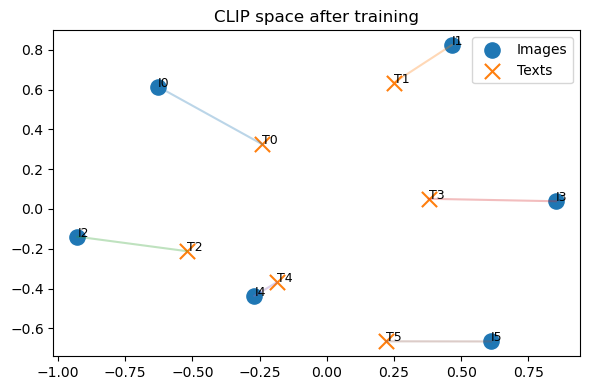

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA


# ----------------------------
# 1. Your data
# ----------------------------
image_paths = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # Two cats
    "http://images.cocodataset.org/val2017/000000000285.jpg",  # Bear
    "http://images.cocodataset.org/val2017/000000000785.jpg",  # Skier
    "http://images.cocodataset.org/val2017/000000001268.jpg",  # person and lake
    "http://images.cocodataset.org/val2017/000000001503.jpg",  # Laptop
    "http://images.cocodataset.org/val2017/000000002299.jpg",  # Children
]

texts = [
    "two cats on the sofa",
    "a big brown bear in the nature",
    "skier on the mountain",
    "a person on the lake",
    "a laptop for working on a table",
    "some childrenposing for a photo"
]

# Ensure the number of images matches the number of captions to maintain valid pairs.
assert len(image_paths) == len(texts)

# ----------------------------
# 2. Simple tokenizer
# ----------------------------
def build_vocab(texts):
    '''
    Build a vocabulary dictionary that assigns a unique integer ID to every word found in the input texts.
    Includes <pad> (index 0) for fixed-length sequences and <unk> (index 1) for words not seen during training.
    '''
    vocab = {"<pad>": 0, "<unk>": 1}
    for text in texts:
        for tok in text.lower().split():
            if tok not in vocab:
                vocab[tok] = len(vocab)
    return vocab

def encode_text(text, vocab, max_len=8):
    '''
    1. Convert text to lowercase, split into words, and map to IDs (use <unk> if word is missing)
    2. Truncate the sequence if it exceeds max_len
    3. Add <pad> tokens to ensure the tensor always has the same shape (max_len)
    4. Return as a PyTorch long tensor
    '''
    tokens = [vocab.get(tok, vocab["<unk>"]) for tok in text.lower().split()]
    tokens = tokens[:max_len]
    tokens += [vocab["<pad>"]] * (max_len - len(tokens))
    return torch.tensor(tokens, dtype=torch.long)


# ----------------------------
# 3. Dataset
# ----------------------------
class ClipToyDataset(Dataset):
    def __init__(self, image_paths, texts, vocab, image_size=64):
        self.image_paths = image_paths
        self.texts = texts
        self.vocab = vocab
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        response = requests.get(self.image_paths[idx])
        img = Image.open(BytesIO(response.content)).convert("RGB").resize((self.image_size, self.image_size))
        # img = Image.open(requests.get(self.image_paths[idx])).convert("RGB").resize((self.image_size, self.image_size))
        img = np.array(img).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)  # C,H,W

        txt = encode_text(self.texts[idx], self.vocab)
        return img, txt, idx


# ----------------------------
# 4. Tiny encoders
# ----------------------------
class ImageEncoder(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(64, emb_dim)

    def forward(self, x):
        x = self.net(x).squeeze(-1).squeeze(-1)
        x = self.proj(x)
        return F.normalize(x, dim=-1)


class TextEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, token_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, token_dim, padding_idx=0)
        self.proj = nn.Linear(token_dim, emb_dim)

    def forward(self, tokens):
        x = self.embedding(tokens)  # B,L,D
        mask = (tokens != 0).float().unsqueeze(-1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        x = self.proj(x)
        return F.normalize(x, dim=-1)


class TinyCLIP(nn.Module):
    def __init__(self, vocab_size, emb_dim=64):
        super().__init__()
        self.image_encoder = ImageEncoder(emb_dim)
        self.text_encoder = TextEncoder(vocab_size, emb_dim)
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))

    def forward(self, images, texts):
        img_emb = self.image_encoder(images)
        txt_emb = self.text_encoder(texts)
        scale = self.logit_scale.exp()
        logits = scale * img_emb @ txt_emb.T
        return logits, img_emb, txt_emb


# ----------------------------
# 5. CLIP loss
# ----------------------------
def clip_loss(logits):
    targets = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, targets)
    loss_t = F.cross_entropy(logits.T, targets)
    return (loss_i + loss_t) / 2


# ----------------------------
# 6. Visualization
# ----------------------------
@torch.no_grad()
def collect_embeddings(model, dataset, device):
    model.eval()
    images = []
    texts = []
    labels = []

    for i in range(len(dataset)):
        img, txt, idx = dataset[i]
        img = img.unsqueeze(0).to(device)
        txt = txt.unsqueeze(0).to(device)

        _, img_emb, txt_emb = model(img, txt)
        images.append(img_emb.squeeze(0).cpu().numpy())
        texts.append(txt_emb.squeeze(0).cpu().numpy())
        labels.append(idx)

    return np.array(images), np.array(texts), labels

def plot_clip_space(img_embs, txt_embs, texts, title, save_path=None):
    all_embs = np.concatenate([img_embs, txt_embs], axis=0)
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_embs)

    n = len(img_embs)
    img_xy = coords[:n]
    txt_xy = coords[n:]

    plt.figure(figsize=(6, 4))
    plt.scatter(img_xy[:, 0], img_xy[:, 1], marker='o', s=120, label='Images')
    plt.scatter(txt_xy[:, 0], txt_xy[:, 1], marker='x', s=120, label='Texts')

    for i in range(n):
        plt.plot(
            [img_xy[i, 0], txt_xy[i, 0]],
            [img_xy[i, 1], txt_xy[i, 1]],
            alpha=0.3
        )
        plt.text(img_xy[i, 0], img_xy[i, 1], f"I{i}", fontsize=9)
        plt.text(txt_xy[i, 0], txt_xy[i, 1], f"T{i}", fontsize=9)

    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


# ----------------------------
# 7. Train
# ----------------------------
def main():
    device = "mps" if torch.mps.is_available() else "cpu"
    vocab = build_vocab(texts)
    dataset = ClipToyDataset(image_paths, texts, vocab)
    loader = DataLoader(dataset, batch_size=10, shuffle=True)

    model = TinyCLIP(vocab_size=len(vocab), emb_dim=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Before training
    img_embs_before, txt_embs_before, _ = collect_embeddings(model, dataset, device)
    plot_clip_space(
        img_embs_before,
        txt_embs_before,
        texts,
        title="CLIP space before training",
        save_path="clip_before.png"
    )

    # Training
    model.train()
    epochs = 100

    for epoch in range(epochs):
        for images, token_ids, _ in loader:
            images = images.to(device)
            token_ids = token_ids.to(device)

            logits, _, _ = model(images, token_ids)
            loss = clip_loss(logits)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:03d} | loss = {loss.item():.4f}")

            # After training
            img_embs_after, txt_embs_after, _ = collect_embeddings(model, dataset, device)
            plot_clip_space(
                img_embs_after,
                txt_embs_after,
                texts,
                title="CLIP space after training",
                save_path="clip_after.png"
            )

if __name__ == "__main__":
    main()

https://github.com/openai/CLIP/blob/dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1/data/prompts.md?plain=1#L517

**N.B.** After the training phase, the image embedding 'I0' and the text embedding 'T0' should appear closely clustered or nearly overlapping in the shared space.

## Zero-Shot Classification

- After training, you can do zero-shot classification:

Write prompts like “a photo of a dog”, “a photo of a cat” → embed them.

Compare with the image embedding → pick the closest.


https://github.com/openai/CLIP/blob/main/clip/model.py

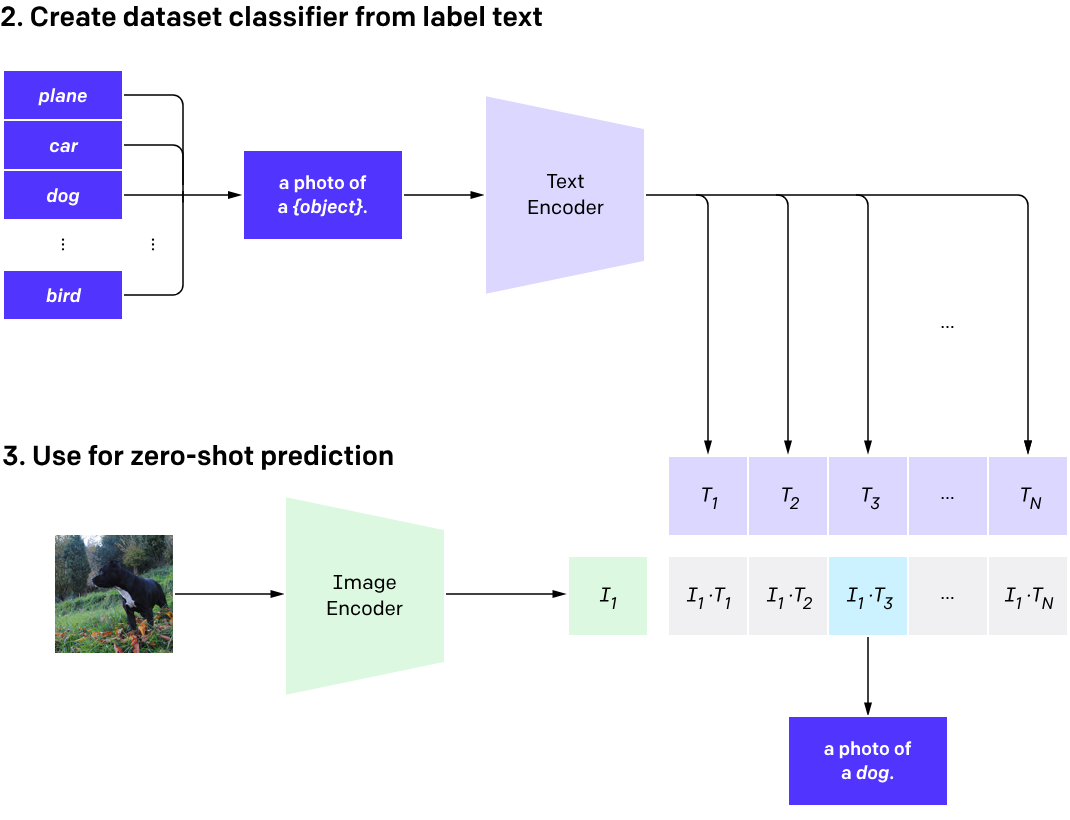

In [17]:
import clip
import requests
import torch
from PIL import Image
from io import BytesIO
import numpy as np

device = "mps" if torch.mps.is_available() else "cpu"

# Load model and preprocess transforms
model, preprocess = clip.load("ViT-B/32", device=device)

In [18]:

# Load image
path = "https://www.veterinarimatera.it/wp-content/uploads/2021/03/cane-1.jpg"
response = requests.get(path)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Processing inputs
# template = "a photo of a {}."
classes = [ "a puppy", "a cat",  "a diagram", "a golden retriever"]
text_tokens = clip.tokenize([f"a photo of a {c}" for c in classes]).to(device)
image = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    logits_per_image, logits_per_text = model(image, text_tokens)
    print(logits_per_image.shape)
    print(logits_per_image)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

print(probs)
np.set_printoptions(precision=4, suppress=True)
print(f"Label probs: {probs}")


torch.Size([1, 4])
tensor([[28.9844, 20.1719, 20.5625, 30.2969]], device='mps:0',
       dtype=torch.float16)
[[2.12e-01 3.16e-05 4.67e-05 7.88e-01]]
Label probs: [[0.212 0.    0.    0.788]]


## Image Retrieval

Top image indices: [0 1 4]
Similarity scores: [0.253  0.1744 0.1652]


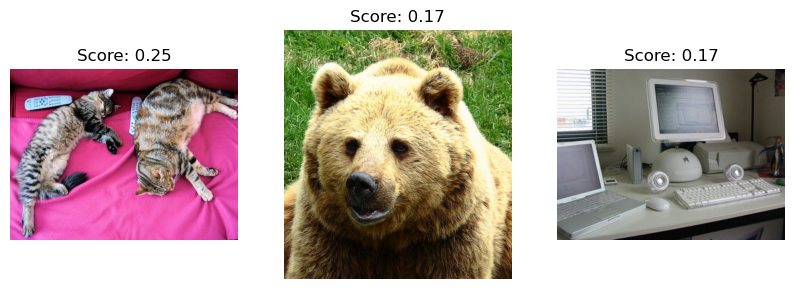

In [19]:
import clip
import requests
import torch
from PIL import Image
from io import BytesIO

device = "mps" if torch.mps.is_available() else "cpu"

# Load model and preprocessing
model, preprocess = clip.load("ViT-B/32", device=device)

# Image URLs
image_urls_diverse = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # Two cats
    "http://images.cocodataset.org/val2017/000000000285.jpg",  # Bear
    "http://images.cocodataset.org/val2017/000000000785.jpg",  # Skier
    "http://images.cocodataset.org/val2017/000000001268.jpg",  # person and lake
    "http://images.cocodataset.org/val2017/000000001503.jpg",  # Laptop
    "http://images.cocodataset.org/val2017/000000002299.jpg",  # Children
]

# Load images
images = []
for url in image_urls_diverse:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    images.append(img)

# Preprocess images
image_tensors = torch.stack([preprocess(img) for img in images]).to(device)

# Text query
text_query = clip.tokenize(["a photo of cat on the couch"]).to(device)

with torch.no_grad():
    # Encode images and text
    image_features = model.encode_image(image_tensors)
    text_features = model.encode_text(text_query)

    # Normalize embeddings
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Cosine similarity: [num_images, 1]
    similarity = (image_features @ text_features.T).squeeze(1)

# Get top 3 most similar images
top_probs, top_idxs = similarity.topk(3)

print("Top image indices:", top_idxs.cpu().numpy())
print("Similarity scores:", top_probs.cpu().numpy())

# Optional: display top images
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i, idx in enumerate(top_idxs):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[idx])
    plt.title(f"Score: {similarity[idx]:.2f}")
    plt.axis("off")
plt.show()


## CLIP as an Evaluation Metric for captioning
https://github.com/jmhessel/clipscore/blob/main/clipscore.py#L135

In [ ]:
def get_clip_score(model, images, candidates, device, w=2.5):
    '''
    get standard image-text clipscore.
    images can either be:
    - a list of strings specifying filepaths for images
    - a precomputed, ordered matrix of image features
    '''
    if isinstance(images, list):
        # need to extract image features
        images = extract_all_images(images, model, device)

    candidates = extract_all_captions(candidates, model, device)

    #Manual Normalization L2
    images = images / np.sqrt(np.sum(images**2, axis=1, keepdims=True))
    candidates = candidates / np.sqrt(np.sum(candidates**2, axis=1, keepdims=True))

    '''
    1. Calculate cosine similarity via dot product (since features are normalized)
    2. Clip values at 0 to remove negative correlations
    3. Scale by w=2.5 for standardized metric reporting
    '''
    per = w*np.clip(np.sum(images * candidates, axis=1), 0, None)
    return np.mean(per), per, candidates